In [1]:
import tensorflow as tf

In [2]:
import tensorflow_datasets as tfds

# IMDB Dataset

In [3]:
train_data = tfds.as_numpy(tfds.load('imdb_reviews', split='train'))

In [4]:
train_data

In [5]:
imdb_sentences = []
imdb_labels = []

for item in train_data:
  # print(item)
  # break
  imdb_sentences.append(str(item['text']))
  imdb_labels.append(item['label'])

In [6]:
len(imdb_sentences)

25000

In [7]:
len(imdb_labels)

25000

In [8]:
imdb_sentences[25]

'b"Well, i rented this movie and found out it realllllllly sucks. It is about that family with the stepmother and the same stupid fights in the family,then the cool son comes with his stupid camera and he likes to take a photo to damaged building and weird things and weird movie ,and then he asks his father to take him to a side trip and simply agrees, etc etc etc..... They go to that town which no one know it exists (blah blah blah) And the most annoying thing is that the movie ends and yet you don\'t understand what is THAT MOVIE!!!!I have seen many mystery movies but that was the worst, Honestly it doesn\'t have a description at all and i wish i didn\'t see it."'

In [9]:
imdb_labels[25]

np.int64(0)

In [10]:
training_sentences = imdb_sentences[:20000]
test_sentences = imdb_sentences[20000:]

training_labels = imdb_labels[:20000]
test_labels = imdb_labels[20000:]

In [11]:
len(training_sentences), len(test_sentences)

(20000, 5000)

# Tokenisation (Phrases --> Liste de Mots)

In [12]:
phrase = "Je suis au marché"

In [13]:
phrase.split(" ")

['Je', 'suis', 'au', 'marché']

In [14]:
phrases = ["Je suis au marché", "Je travaille au marché"]

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [16]:
tokenizer = Tokenizer()

In [17]:
tokenizer.fit_on_texts(phrases)

In [18]:
tokenizer.word_index

{'je': 1, 'au': 2, 'marché': 3, 'suis': 4, 'travaille': 5}

In [19]:
tokenizer.index_word

{1: 'je', 2: 'au', 3: 'marché', 4: 'suis', 5: 'travaille'}

In [20]:
tokenizer.texts_to_sequences(phrases)

[[1, 4, 2, 3], [1, 5, 2, 3]]

In [21]:
test = ['Je vends au Marché']

In [22]:
tokenizer.texts_to_sequences(test) # je au marché

[[1, 2, 3]]

In [23]:
test = ['Hello, viens']

In [24]:
tokenizer.texts_to_sequences(test)

[[]]

In [25]:
tokenizer = Tokenizer(num_words=100, oov_token="<OOV>")
tokenizer.fit_on_texts(phrases)

In [26]:
tokenizer.word_index

{'<OOV>': 1, 'je': 2, 'au': 3, 'marché': 4, 'suis': 5, 'travaille': 6}

In [27]:
test = ['Je vends au Marché']
tokenizer.texts_to_sequences(test)

[[2, 1, 3, 4]]

# Padding

In [28]:
phrases = ["Je suis au marché",
           "Je travaille au marché",
           "es-tu rentré du marché?",
           "Je nettoie le marché tous les jours avant de commencer à vendre le matin"]

tokenizer = Tokenizer(num_words = 100, oov_token="<OOV>")
tokenizer.fit_on_texts(phrases)
word_index = tokenizer.word_index
sequences = tokenizer.texts_to_sequences(phrases)

In [29]:
sequences

[[3, 6, 4, 2],
 [3, 7, 4, 2],
 [8, 9, 10, 11, 2],
 [3, 12, 5, 2, 13, 14, 15, 16, 17, 18, 19, 20, 5, 21]]

In [30]:
word_index

{'<OOV>': 1,
 'marché': 2,
 'je': 3,
 'au': 4,
 'le': 5,
 'suis': 6,
 'travaille': 7,
 'es': 8,
 'tu': 9,
 'rentré': 10,
 'du': 11,
 'nettoie': 12,
 'tous': 13,
 'les': 14,
 'jours': 15,
 'avant': 16,
 'de': 17,
 'commencer': 18,
 'à': 19,
 'vendre': 20,
 'matin': 21}

In [31]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [32]:
sequences

[[3, 6, 4, 2],
 [3, 7, 4, 2],
 [8, 9, 10, 11, 2],
 [3, 12, 5, 2, 13, 14, 15, 16, 17, 18, 19, 20, 5, 21]]

In [33]:
pad_sequences(sequences)

array([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  3,  6,  4,  2],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  3,  7,  4,  2],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  8,  9, 10, 11,  2],
       [ 3, 12,  5,  2, 13, 14, 15, 16, 17, 18, 19, 20,  5, 21]],
      dtype=int32)

In [34]:
pad_sequences(sequences, padding="post")

array([[ 3,  6,  4,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 3,  7,  4,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 8,  9, 10, 11,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 3, 12,  5,  2, 13, 14, 15, 16, 17, 18, 19, 20,  5, 21]],
      dtype=int32)

In [35]:
pad_sequences(sequences, padding="post", maxlen=7)

array([[ 3,  6,  4,  2,  0,  0,  0],
       [ 3,  7,  4,  2,  0,  0,  0],
       [ 8,  9, 10, 11,  2,  0,  0],
       [16, 17, 18, 19, 20,  5, 21]], dtype=int32)

In [36]:
pad_sequences(sequences, padding="post", maxlen=7, truncating="post")

array([[ 3,  6,  4,  2,  0,  0,  0],
       [ 3,  7,  4,  2,  0,  0,  0],
       [ 8,  9, 10, 11,  2,  0,  0],
       [ 3, 12,  5,  2, 13, 14, 15]], dtype=int32)

# Stop words

In [37]:
phrase = "Je vais au marché le Jeudi"

In [38]:
stopwords = ['au', "le"]

In [39]:
words = phrase.split(' ')
phrase_nettoyee = []

for word in words:
  if word not in stopwords:
    phrase_nettoyee.append(word)

In [40]:
phrase_nettoyee

['Je', 'vais', 'marché', 'Jeudi']

In [41]:
" ".join(phrase_nettoyee)

'Je vais marché Jeudi'

# Approche de calcul du Sentiment

In [42]:
phrase = "Votre connexion est lente"

In [43]:
{5 : 0}

{5: 0}

In [44]:
phrase = "Votre connexion est agréablement lente"

In [45]:
{"Votre": [1, 0, 5],
 "connexion": [0, 1, 9],
 "est": [3, 2, 3],
 "agréablement": [2, 3, 12],
 "lente": [5, 4, 5]}

{'Votre': [1, 0, 5],
 'connexion': [0, 1, 9],
 'est': [3, 2, 3],
 'agréablement': [2, 3, 12],
 'lente': [5, 4, 5]}

# Embedding (plongement)

In [46]:
training_sentences[42]

'b\'One of the weaker Carry On adventures sees Sid James as the head of a crime gang stealing contraceptive pills. The fourth of the series to be hospital-based, it\\\'s possibly the least of the genre. There\\\'s a curiously flat feel throughout, with all seemingly squandered on below-par material. This is far from the late-70s nadir, but Williams, James, Bresslaw, Maynard et al. are all class performers yet not given the backing of a script equal to their ability.<br /><br />Most of the gags are onrunning, rather than episodic as Carry Ons usually are. So that instead of the traditional hit and miss ratio, if you don\\\'t find the joke funny in the first place you\\\'re stuck with it for most of the film. These continuous plot strands include Williams \\xc2\\x96 for no good reason \\xc2\\x96 worrying that he\\\'s changing sex, and Kenneth Cope in drag. Like the stagy physical pratt falls, the whole thing feels more contrived than in other movies, and lacking in cast interest. Continu

In [47]:
training_labels[42]

np.int64(0)

In [48]:
# vocab_size, embedding_dim (78371)

In [49]:
tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer.fit_on_texts(training_sentences)
word_index = tokenizer.word_index

training_sequences = tokenizer.texts_to_sequences(training_sentences)
training_padded = pad_sequences(training_sequences, padding="post", maxlen=15, truncating="post")

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, padding="post", maxlen=15, truncating="post")


In [50]:
training_padded[42]

array([4668,    5,    2, 5838, 1706,   22, 2438, 1117, 5099,  594,   15,
          2,  423,    5,    4], dtype=int32)

In [51]:
import numpy as np

training_labels = np.array(training_labels)
test_labels = np.array(test_labels)

In [52]:
model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(20000, 20),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

In [53]:
model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])

In [54]:
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True)

In [55]:
h = model.fit(training_padded, training_labels, epochs=50,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp, stop])

Epoch 1/50
619/625 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5664 - loss: 0.6775

625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5670 - loss: 0.6772 - val_accuracy: 0.6844 - val_loss: 0.5940
Epoch 2/50
617/625 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7538 - loss: 0.5147

625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7538 - loss: 0.5146 - val_accuracy: 0.7018 - val_loss: 0.5767
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8115 - loss: 0.4223 - val_accuracy: 0.6958 - val_loss: 0.6101
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8412 - loss: 0.3675 - val_accuracy: 0.6910 - val_loss: 0.6503
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8583 - loss: 0.3323 - val_accuracy: 0.6854 - val_loss: 0.6948
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8806 - loss: 0.2923 - val_accuracy: 0.6846 - val_loss: 0.7289


In [56]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (32, 15, 20)           │       400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (32, 20)               │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 8)                │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 1)                │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,200,533 (4.58 MB)

 Trainable params: 400,177 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 800,356 (3.05 MB)

In [57]:
20*8 + 8

168

In [58]:
import matplotlib.pyplot as plt


def plot_graphs(history, string):
    plt.plot(history.history[string])
    plt.plot(history.history['val_'+string])
    plt.xlabel("Epochs")
    plt.ylabel(string)
    plt.legend([string, 'val_'+string])
    plt.grid()
    plt.show()

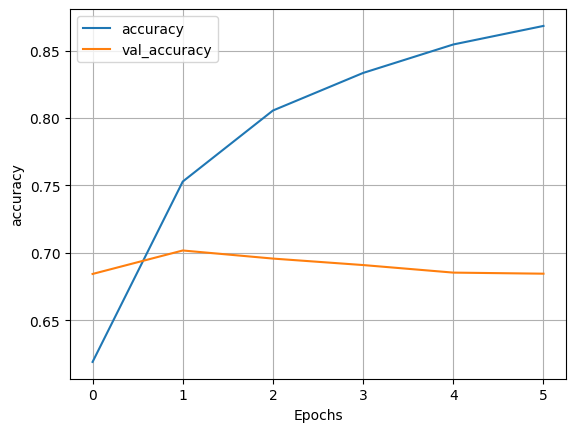

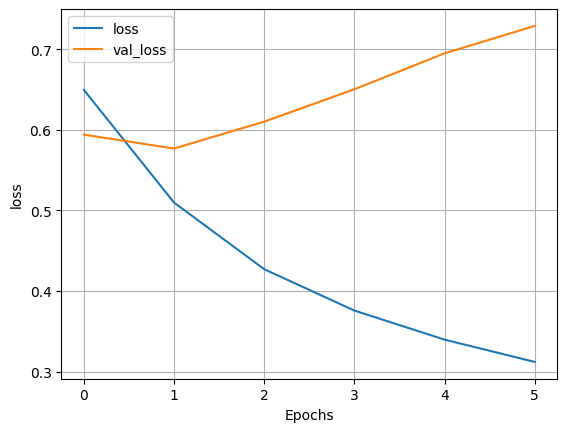

In [59]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")

# Vocab size

In [60]:
# 20000

vocab_size = 1

vocab_size = 78371

In [61]:
len(word_index)

78371

In [62]:
(78371* 20)

1567420

In [63]:
wc = tokenizer.word_counts

In [64]:
wc = sorted(wc.items(), key=lambda t:t[1], reverse=True)

In [65]:
import pandas as pd

In [66]:
df = pd.DataFrame(wc, columns=['mots', "frequence"])

In [67]:
df[df['frequence'] > 10]

,mots,frequence
0,the,268774
1,and,131448
2,a,130000
3,of,116684
4,to,108554
...,...,...
17156,crockett,11
17157,liliom,11
17158,nikhil,11
17159,hanka,11


In [68]:
test_tok = Tokenizer()
test_tok.fit_on_texts(test_sentences)

In [69]:
test_tok.word_index

{'the': 1,
 'a': 2,
 'and': 3,
 'of': 4,
 'to': 5,
 'is': 6,
 'br': 7,
 'in': 8,
 'it': 9,
 'i': 10,
 'this': 11,
 'that': 12,
 'was': 13,
 'as': 14,
 'with': 15,
 'for': 16,
 'movie': 17,
 'but': 18,
 'film': 19,
 "'s": 20,
 'on': 21,
 'you': 22,
 'not': 23,
 'he': 24,
 'are': 25,
 'his': 26,
 'have': 27,
 'be': 28,
 'one': 29,
 'all': 30,
 'by': 31,
 'at': 32,
 'an': 33,
 'they': 34,
 'who': 35,
 'from': 36,
 'so': 37,
 'like': 38,
 'her': 39,
 'just': 40,
 'or': 41,
 "'t": 42,
 'about': 43,
 'has': 44,
 'out': 45,
 'there': 46,
 "'": 47,
 'if': 48,
 'some': 49,
 'good': 50,
 'what': 51,
 'more': 52,
 'when': 53,
 'very': 54,
 'she': 55,
 'up': 56,
 'b': 57,
 'no': 58,
 'even': 59,
 'can': 60,
 'time': 61,
 'my': 62,
 'which': 63,
 'only': 64,
 'story': 65,
 'would': 66,
 'really': 67,
 'see': 68,
 'their': 69,
 'had': 70,
 'were': 71,
 'well': 72,
 'me': 73,
 'we': 74,
 'than': 75,
 'much': 76,
 'get': 77,
 'bad': 78,
 'because': 79,
 'great': 80,
 'other': 81,
 'into': 82,
 'will':

In [70]:
test_words = test_tok.word_index.keys()

In [71]:
test_words

dict_keys(['the', 'a', 'and', 'of', 'to', 'is', 'br', 'in', 'it', 'i', 'this', 'that', 'was', 'as', 'with', 'for', 'movie', 'but', 'film', "'s", 'on', 'you', 'not', 'he', 'are', 'his', 'have', 'be', 'one', 'all', 'by', 'at', 'an', 'they', 'who', 'from', 'so', 'like', 'her', 'just', 'or', "'t", 'about', 'has', 'out', 'there', "'", 'if', 'some', 'good', 'what', 'more', 'when', 'very', 'she', 'up', 'b', 'no', 'even', 'can', 'time', 'my', 'which', 'only', 'story', 'would', 'really', 'see', 'their', 'had', 'were', 'well', 'me', 'we', 'than', 'much', 'get', 'bad', 'because', 'great', 'other', 'into', 'will', 'been', 'people', 'first', 'also', 'most', 'him', 'how', 'do', 'made', 'them', 'way', 'then', 'too', 'could', 'its', "it's", 'make', 'any', 'movies', 'after', 'think', 'films', 'characters', 'watch', 'seen', 'life', 'many', 'character', 'two', 'little', 'know', 'acting', 'best', 'plot', 'where', 'show', 'being', 'off', 'did', 'over', 'never', 'does', 'love', 'ever', 'man', 'here', 'bette

In [72]:
train_words = df['mots'].tolist()

In [73]:
len(train_words), len(test_words)

(78370, 42047)

In [74]:
inter = set(train_words).intersection(test_words)

In [75]:
len(inter)

33879

In [76]:
vocab_size = 29000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(training_sentences)
word_index = tokenizer.word_index

training_sequences = tokenizer.texts_to_sequences(training_sentences)
training_padded = pad_sequences(training_sequences, padding="post", maxlen=15, truncating="post")

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, padding="post", maxlen=15, truncating="post")

model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(vocab_size, 20),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True)
h = model.fit(training_padded, training_labels, epochs=50,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp, stop])

Epoch 1/50
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5798 - loss: 0.6746

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5801 - loss: 0.6744 - val_accuracy: 0.6856 - val_loss: 0.5892
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7674 - loss: 0.5037

625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7674 - loss: 0.5036 - val_accuracy: 0.6958 - val_loss: 0.5788
Epoch 3/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8261 - loss: 0.4096

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8261 - loss: 0.4096 - val_accuracy: 0.6978 - val_loss: 0.6082
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8546 - loss: 0.3482 - val_accuracy: 0.6898 - val_loss: 0.6552
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8781 - loss: 0.3015 - val_accuracy: 0.6856 - val_loss: 0.7072
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8937 - loss: 0.2709 - val_accuracy: 0.6884 - val_loss: 0.7584
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9021 - loss: 0.2509 - val_accuracy: 0.6812 - val_loss: 0.8073


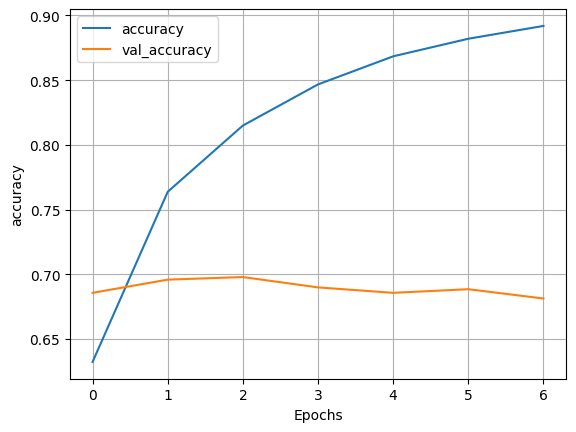

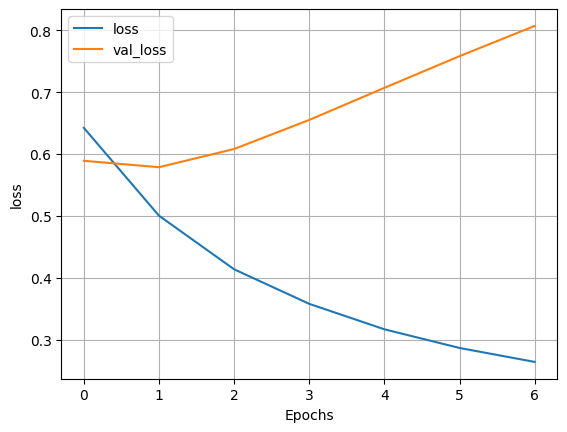

In [77]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")

# Embedding dim

In [78]:
np.power(vocab_size, 1/4)

np.float64(13.049669101523763)

In [79]:
vocab_size = 29000
embedding_dim=13

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(training_sentences)
word_index = tokenizer.word_index

training_sequences = tokenizer.texts_to_sequences(training_sentences)
training_padded = pad_sequences(training_sequences, padding="post", maxlen=15, truncating="post")

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, padding="post", maxlen=15, truncating="post")

model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(vocab_size, embedding_dim),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True)
h = model.fit(training_padded, training_labels, epochs=50,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp, stop])

Epoch 1/50
617/625 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5678 - loss: 0.6810

625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5686 - loss: 0.6807 - val_accuracy: 0.6864 - val_loss: 0.6003
Epoch 2/50
616/625 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7498 - loss: 0.5303

625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7499 - loss: 0.5301 - val_accuracy: 0.6950 - val_loss: 0.5753
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8187 - loss: 0.4188 - val_accuracy: 0.6940 - val_loss: 0.6006
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8514 - loss: 0.3613 - val_accuracy: 0.6926 - val_loss: 0.6453
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8697 - loss: 0.3179 - val_accuracy: 0.6858 - val_loss: 0.6934
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8876 - loss: 0.2866 - val_accuracy: 0.6798 - val_loss: 0.7373


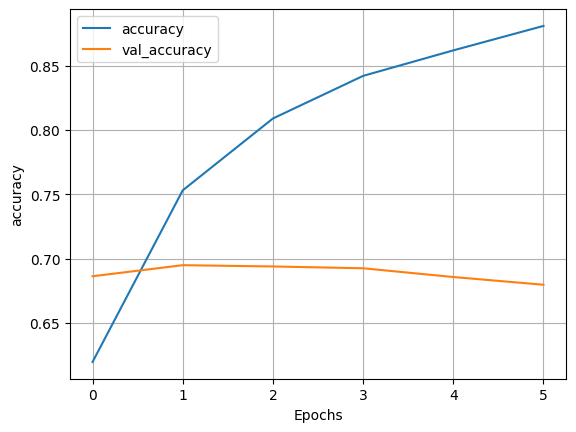

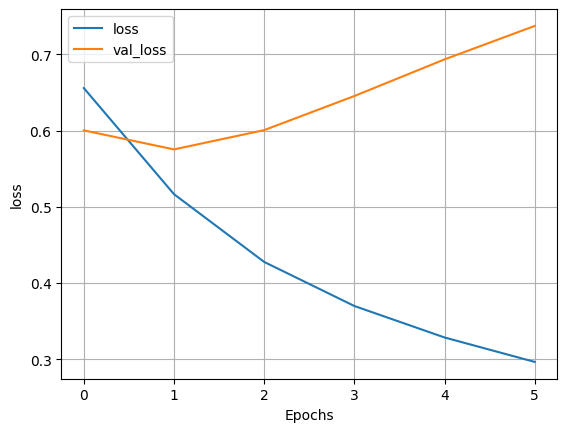

In [80]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")

# Architecture du model

In [81]:
vocab_size = 29000
embedding_dim=13

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(training_sentences)
word_index = tokenizer.word_index

training_sequences = tokenizer.texts_to_sequences(training_sentences)
training_padded = pad_sequences(training_sequences, padding="post", maxlen=15, truncating="post")

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, padding="post", maxlen=15, truncating="post")

model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(vocab_size, embedding_dim),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(5, activation='relu'),
        tf.keras.layers.Dense(3, activation='relu'), # <= Ajout d'une couche
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True)
h = model.fit(training_padded, training_labels, epochs=50,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp, stop])

Epoch 1/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5518 - loss: 0.6839

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5520 - loss: 0.6838 - val_accuracy: 0.6864 - val_loss: 0.6238
Epoch 2/50
618/625 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7546 - loss: 0.5609

625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7546 - loss: 0.5608 - val_accuracy: 0.6898 - val_loss: 0.5944
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8141 - loss: 0.4661 - val_accuracy: 0.6898 - val_loss: 0.6207
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8484 - loss: 0.3981 - val_accuracy: 0.6824 - val_loss: 0.6613
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8718 - loss: 0.3505 - val_accuracy: 0.6802 - val_loss: 0.6940
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8830 - loss: 0.3243 - val_accuracy: 0.6726 - val_loss: 0.7684


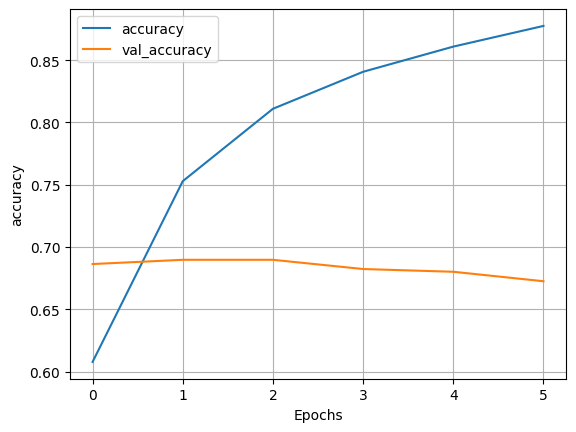

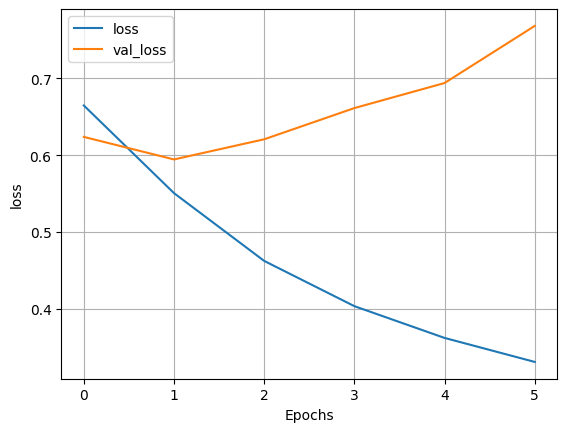

In [82]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")

# Max len + Dropout

In [83]:
tailles = []

for sent in training_sentences:
  tailles.append(len(sent.split(" ")))

In [84]:
np.array(tailles).min(), np.array(tailles).max(), np.array(tailles).mean()

(np.int64(10), np.int64(2470), np.float64(233.90165))

In [85]:
np.median(tailles)

np.float64(174.0)

In [86]:
vocab_size = 29000
embedding_dim=13
maxlen = 100 # Précisé (Était de 15 avant...)

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(training_sentences)
word_index = tokenizer.word_index

training_sequences = tokenizer.texts_to_sequences(training_sentences)
training_padded = pad_sequences(training_sequences, padding="post", maxlen=maxlen, truncating="post")

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, padding="post", maxlen=maxlen, truncating="post")

model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(vocab_size, embedding_dim),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(5, activation='relu'),
        tf.keras.layers.Dropout(0.25), # Ajout d'un dropout
        tf.keras.layers.Dense(3, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=12, restore_best_weights=True)
h = model.fit(training_padded, training_labels, epochs=50,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp, stop])

Epoch 1/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5587 - loss: 0.6797

625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.5589 - loss: 0.6796 - val_accuracy: 0.7776 - val_loss: 0.5480
Epoch 2/50
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8195 - loss: 0.4977

625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8195 - loss: 0.4976 - val_accuracy: 0.8290 - val_loss: 0.4449
Epoch 3/50
620/625 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8911 - loss: 0.3605

625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8911 - loss: 0.3604 - val_accuracy: 0.8370 - val_loss: 0.4162
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9171 - loss: 0.2787 - val_accuracy: 0.8342 - val_loss: 0.4399
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9389 - loss: 0.2219 - val_accuracy: 0.8330 - val_loss: 0.4859
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9505 - loss: 0.1851 - val_accuracy: 0.8266 - val_loss: 0.5224
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9605 - loss: 0.1554 - val_accuracy: 0.8222 - val_loss: 0.6191
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9652 - loss: 0.1386 - val_accuracy: 0.8292 - val_loss: 0.6687
Epoch 9/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9703 - loss: 0.1211 - val_accuracy: 0.8248 - val_loss: 0.7504
Epoch 10/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9686 - loss: 0.1192 - val_accuracy: 0.8240 - val

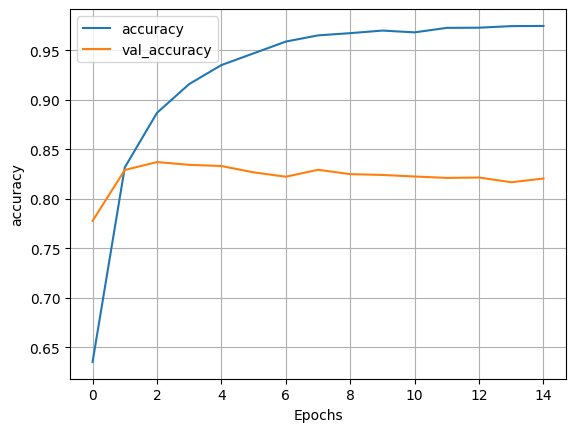

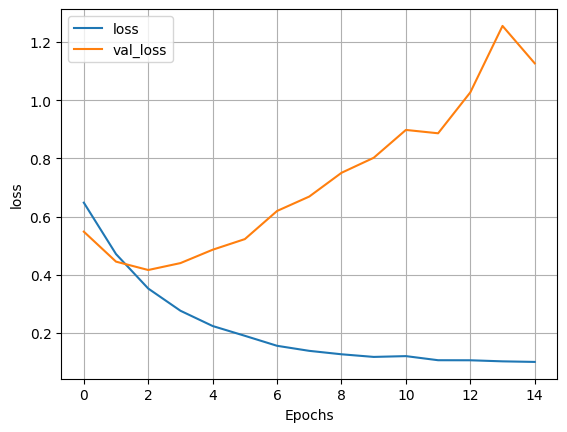

In [87]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")

# Transfert Learning

In [88]:
!pip install --upgrade tensorflow_hub

In [89]:
import tensorflow_hub as hub

In [90]:
embed = hub.load("https://tfhub.dev/google/tf2-preview/gnews-swivel-20dim/1")
embeddings = embed(["cat is on the mat", "dog is in the fog"])

In [91]:
embeddings.shape

TensorShape([2, 20])

In [92]:
train_data, test_data = tfds.load(name="imdb_reviews", split=["train", "test"],
                                  batch_size=-1, as_supervised=True)

train_examples, train_labels = tfds.as_numpy(train_data)
test_examples, test_labels = tfds.as_numpy(test_data)

In [102]:
train_examples[0]

b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it."

In [93]:
training_sentences = train_examples[:20000]
training_labels = train_labels[:20000]

test_sentences = train_examples[20000:]
test_labels = train_labels[20000:]

In [94]:
train_labels[20000:]

array([0, 1, 1, ..., 0, 0, 1])

In [95]:
train_examples[0]

b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it."

In [96]:
hub_layer = hub.KerasLayer("https://tfhub.dev/google/tf2-preview/gnews-swivel-20dim/1", output_shape=[20],
                           input_shape=[], dtype=tf.string)

In [97]:
# model = tf.keras.models.Sequential(
#     [
#         hub.KerasLayer("https://tfhub.dev/google/tf2-preview/gnews-swivel-20dim/1", output_shape=[20],
#                            input_shape=[], dtype=tf.string),
#         tf.keras.layers.Dense(5, activation='relu'),
#         tf.keras.layers.Dropout(0.25),
#         tf.keras.layers.Dense(3, activation='relu'),
#         tf.keras.layers.Dense(1, activation='sigmoid')
#     ]
# )

# model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
# model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
#                             monitor="val_accuracy",
#                             mode="max",
#                             save_best_only=True)
# stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True)
# h = model.fit(training_sentences, training_labels, epochs=50,
#               validation_data=(test_sentences, test_labels),
#               callbacks=[model_ckp, stop])

In [98]:
!pip uninstall -y tensorflow tensorflow-hub

Found existing installation: tensorflow 2.19.1
Uninstalling tensorflow-2.19.1:
  Successfully uninstalled tensorflow-2.19.1
Found existing installation: tensorflow-hub 0.16.1
Uninstalling tensorflow-hub-0.16.1:
  Successfully uninstalled tensorflow-hub-0.16.1


In [99]:
!pip install tensorflow tensorflow-hub

  Using cached tensorflow-2.20.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.5 kB)
  Using cached tensorflow_hub-0.16.1-py2.py3-none-any.whl.metadata (1.3 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached tensorflow-2.19.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
Using cached tensorflow_hub-0.16.1-py2.py3-none-any.whl (30 kB)
Using cached tensorflow-2.19.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (645.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.19.1 which is incompatible.


In [100]:
import tensorflow as tf
import tensorflow_hub as hub

hub_layer_test = hub.KerasLayer("https://tfhub.dev/google/tf2-preview/gnews-swivel-20dim/1", output_shape=[20],
                           input_shape=[], dtype=tf.string)

print(type(hub_layer_test))
print(isinstance(hub_layer_test, tf.keras.layers.Layer))

<class 'tensorflow_hub.keras_layer.KerasLayer'>
False


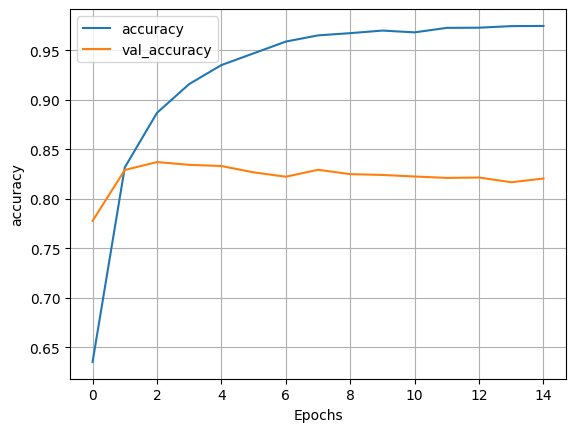

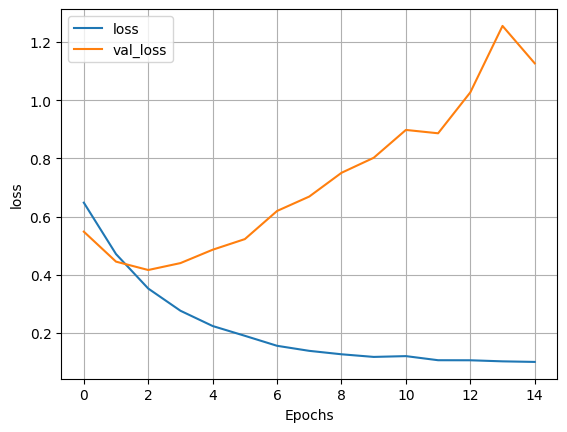

In [101]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")